# Phase 1 — Data Collection & Preprocessing
**XAI Healthcare Diagnostics Project**

This notebook covers:
1. Environment setup & GPU check
2. Dataset download (ChestX-ray14 + ISIC 2019)
3. Exploratory data analysis (class distributions, sample images)
4. Preprocessing pipeline validation
5. DataLoader creation & batch inspection
6. Save dataset split CSVs for reproducibility

---
> **Run cells top-to-bottom.** Each section is self-contained.

## 0. Setup & GPU Check

In [1]:
# Install dependencies (uncomment if on Colab)
# !pip install torch torchvision albumentations grad-cam shap lime captum tqdm -q
# !pip install kaggle -q

import sys, os
sys.path.append('..')  # so we can import from src/

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# Project imports
from src.preprocessing.preprocess import (
    build_chestxray_df, split_chestxray, get_chestxray_loaders,
    build_isic_df, split_isic, get_isic_loaders,
    compute_dataset_stats, CHESTXRAY_LABELS, ISIC_LABELS,
    get_train_transforms, get_val_transforms,
    IMAGENET_MEAN, IMAGENET_STD,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠ No GPU detected. Training will be slow — use Google Colab for GPU.')

PyTorch  : 2.11.0+cpu
Device   : cpu
⚠ No GPU detected. Training will be slow — use Google Colab for GPU.


## 1. Download Datasets

Run this cell once. It downloads both datasets via the Kaggle API.

In [2]:
# ── Option A: Kaggle API (recommended) ──────────────────────
# Make sure ~/.kaggle/kaggle.json exists first.

import subprocess

def download(slug, dest):
    Path(dest).mkdir(parents=True, exist_ok=True)
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', slug, '-p', dest, '--unzip'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f'✓ Downloaded {slug}')
    else:
        print(f'✗ Failed: {result.stderr[:300]}')

# Uncomment to download:
# download('nih-chest-xrays/data',  '../data/chestxray')   # ~45 GB
# download('andrewmvd/isic-2019',   '../data/isic')         # ~10 GB

# ── Option B: Manual download ────────────────────────────────
# ChestX-ray14: https://www.kaggle.com/datasets/nih-chest-xrays/data
# ISIC 2019:    https://www.kaggle.com/datasets/andrewmvd/isic-2019
# Extract both into their respective data/ folders.

print('Update paths below to point to your data folders.')
CHESTXRAY_ROOT = '../data/chestxray'
ISIC_ROOT      = '../data/isic'

Update paths below to point to your data folders.


## 2. ChestX-ray14 — EDA

In [3]:
df_cx = build_chestxray_df(CHESTXRAY_ROOT)
stats_cx = compute_dataset_stats('chestxray', df_cx)
print(f'\nDataFrame shape: {df_cx.shape}')
df_cx.head(3)


── ChestX-ray14 Statistics ──────────────────
  Total images : 112,120
  No Finding   : 60,361
  Label counts :
    Atelectasis            11,559  █████
    Cardiomegaly            2,776  █
    Effusion               13,317  ██████
    Infiltration           19,894  █████████
    Mass                    5,782  ██
    Nodule                  6,331  ███
    Pneumonia               1,431  
    Pneumothorax            5,302  ██
    Consolidation           4,667  ██
    Edema                   2,303  █
    Emphysema               2,516  █
    Fibrosis                1,686  
    Pleural_Thickening      3,385  █
    Hernia                    227  

DataFrame shape: (112120, 15)


,image_path,Atelectasis,Cardiomegaly,Effusion,Infiltration,Mass,Nodule,Pneumonia,Pneumothorax,Consolidation,Edema,Emphysema,Fibrosis,Pleural_Thickening,Hernia
0,..\data\chestxray\images_001\images\00000001_0...,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,..\data\chestxray\images_001\images\00000001_0...,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2,..\data\chestxray\images_001\images\00000001_0...,0,1,1,0,0,0,0,0,0,0,0,0,0,0


C:\Users\VOOTURI ARJUN\AppData\Local\Temp\ipykernel_20008\3703141857.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_counts.index, rotation=40, ha='right')


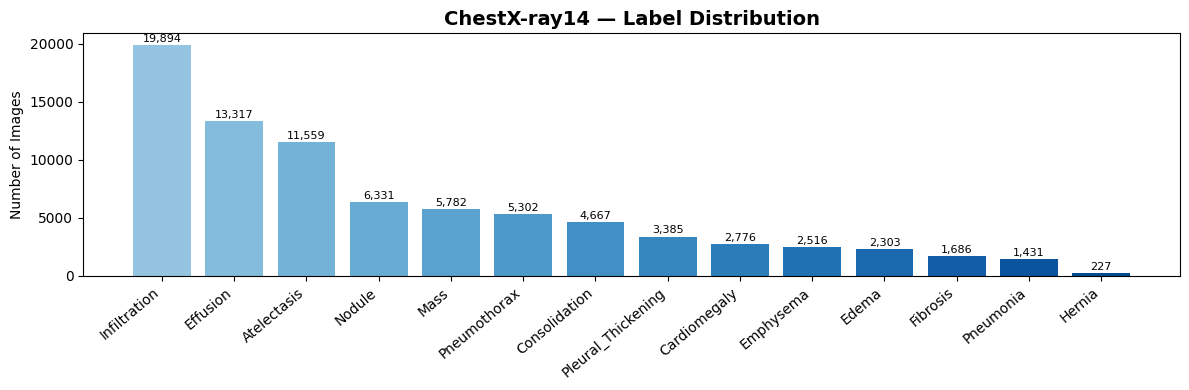

In [4]:
# Class distribution bar chart
label_counts = df_cx[CHESTXRAY_LABELS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(label_counts.index, label_counts.values,
              color=plt.cm.Blues(np.linspace(0.4, 0.9, len(CHESTXRAY_LABELS))))
ax.set_title('ChestX-ray14 — Label Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_xticklabels(label_counts.index, rotation=40, ha='right')
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/reports/chestxray_label_dist.png', dpi=150)
plt.show()

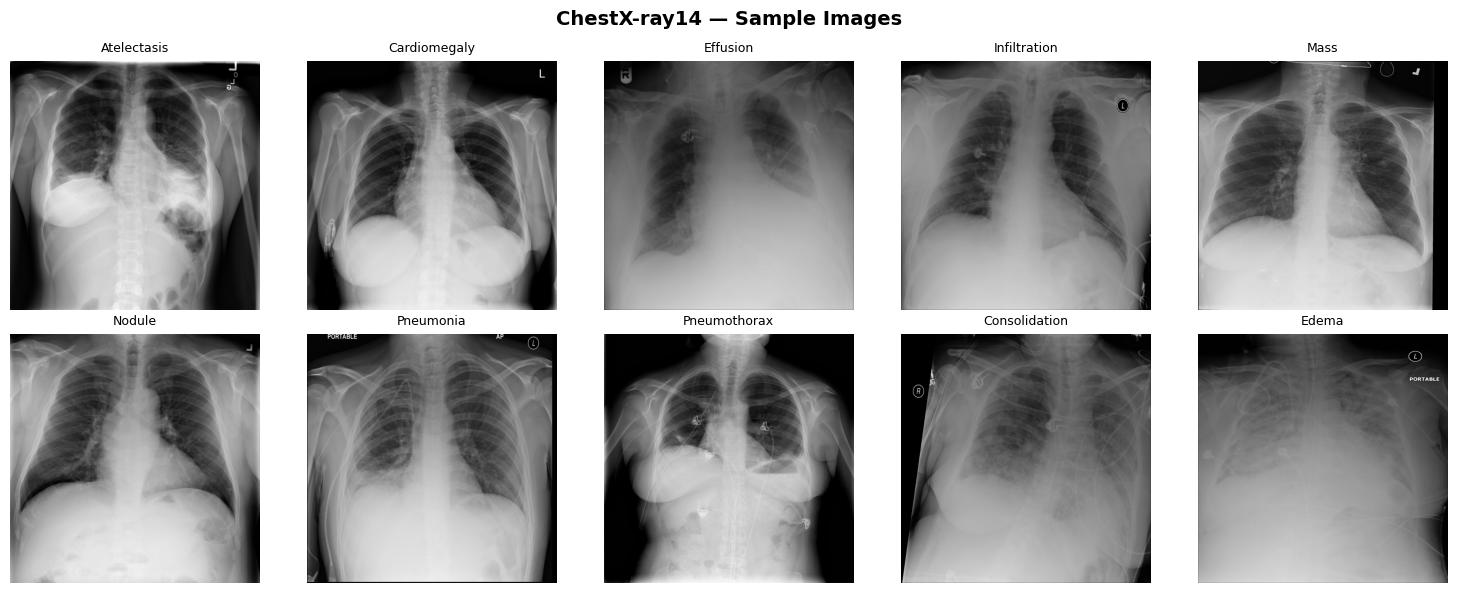

In [5]:
# Sample images grid — ChestX-ray14
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('ChestX-ray14 — Sample Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # Pick a sample for each of the first 10 labels
    label = CHESTXRAY_LABELS[i]
    sample = df_cx[df_cx[label] == 1].sample(1, random_state=i)
    img = Image.open(sample['image_path'].values[0]).convert('RGB')
    ax.imshow(img, cmap='gray')
    ax.set_title(label, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/reports/chestxray_samples.png', dpi=150)
plt.show()

## 3. ISIC 2019 — EDA

In [6]:
import os
os.chdir(r'C:\Users\VOOTURI ARJUN\Downloads\xai_project')
print(os.getcwd())

C:\Users\VOOTURI ARJUN\Downloads\xai_project


In [7]:
import os
os.chdir(r'C:\Users\VOOTURI ARJUN\Downloads\xai_project')

CHESTXRAY_ROOT = 'data/chestxray'
ISIC_ROOT      = 'data/isic'

print(os.getcwd())
print(os.path.exists(ISIC_ROOT))

C:\Users\VOOTURI ARJUN\Downloads\xai_project
True


In [8]:
import pandas as pd
gt = pd.read_csv('data/isic/ISIC_2019_Training_GroundTruth.csv')
print(gt.columns.tolist())
print(gt.head(3))

['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0


In [9]:
def build_isic_df_fixed(data_root):
    from pathlib import Path
    import numpy as np
    import pandas as pd
    
    ISIC_LABELS = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
    data_root = Path(data_root)
    csv_path = data_root / "ISIC_2019_Training_GroundTruth.csv"
    gt = pd.read_csv(csv_path)
    img_dir = data_root / "ISIC_2019_Training_Input" / "ISIC_2019_Training_Input"

    records = []
    for _, row in gt.iterrows():
        img_id = row["image"]
        img_path = img_dir / f"{img_id}.jpg"
        if not img_path.exists():
            continue
        label_idx = int(np.argmax(row[ISIC_LABELS].values))
        records.append({
            "image_path": str(img_path),
            "label": label_idx,
            "class_name": ISIC_LABELS[label_idx],
        })

    df = pd.DataFrame(records)
    print(f"Loaded {len(df):,} ISIC images")
    return df

df_is = build_isic_df_fixed(ISIC_ROOT)
print(df_is.head(3))

Loaded 25,331 ISIC images
                                          image_path  label class_name
0  data\isic\ISIC_2019_Training_Input\ISIC_2019_T...      1         NV
1  data\isic\ISIC_2019_Training_Input\ISIC_2019_T...      1         NV
2  data\isic\ISIC_2019_Training_Input\ISIC_2019_T...      0        MEL


Loaded 25,331 ISIC images

── ISIC 2019 Statistics ─────────────────────
  Total images : 25,331
  Class counts :
    NV     12,875  ████████████████████████████████████████████████████████████████
    MEL     4,522  ██████████████████████
    BCC     3,323  ████████████████
    BKL     2,624  █████████████
    AK        867  ████
    SCC       628  ███
    VASC      253  █
    DF        239  █


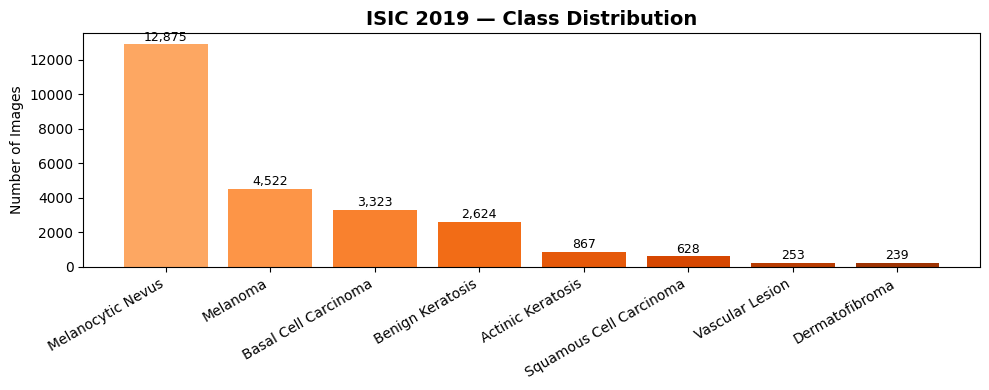

✓ ISIC chart saved


In [10]:
# ISIC Statistics + Chart (bypasses old preprocess.py function)
df_is = build_isic_df_fixed(ISIC_ROOT)

print(f"\n── ISIC 2019 Statistics ─────────────────────")
print(f"  Total images : {len(df_is):,}")
print(f"  Class counts :")
for cls, count in df_is['class_name'].value_counts().items():
    bar = "█" * (count // 200)
    print(f"    {cls:<6} {count:>6,}  {bar}")

# Chart
counts = df_is['class_name'].value_counts()
full_names = {
    'MEL':'Melanoma','NV':'Melanocytic Nevus','BCC':'Basal Cell Carcinoma',
    'AK':'Actinic Keratosis','BKL':'Benign Keratosis','DF':'Dermatofibroma',
    'VASC':'Vascular Lesion','SCC':'Squamous Cell Carcinoma'
}
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(counts)))
bars = ax.bar([full_names.get(c,c) for c in counts.index], counts.values, color=colors)
ax.set_title('ISIC 2019 — Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/reports/isic_label_dist.png', dpi=150)
plt.show()
print('✓ ISIC chart saved')

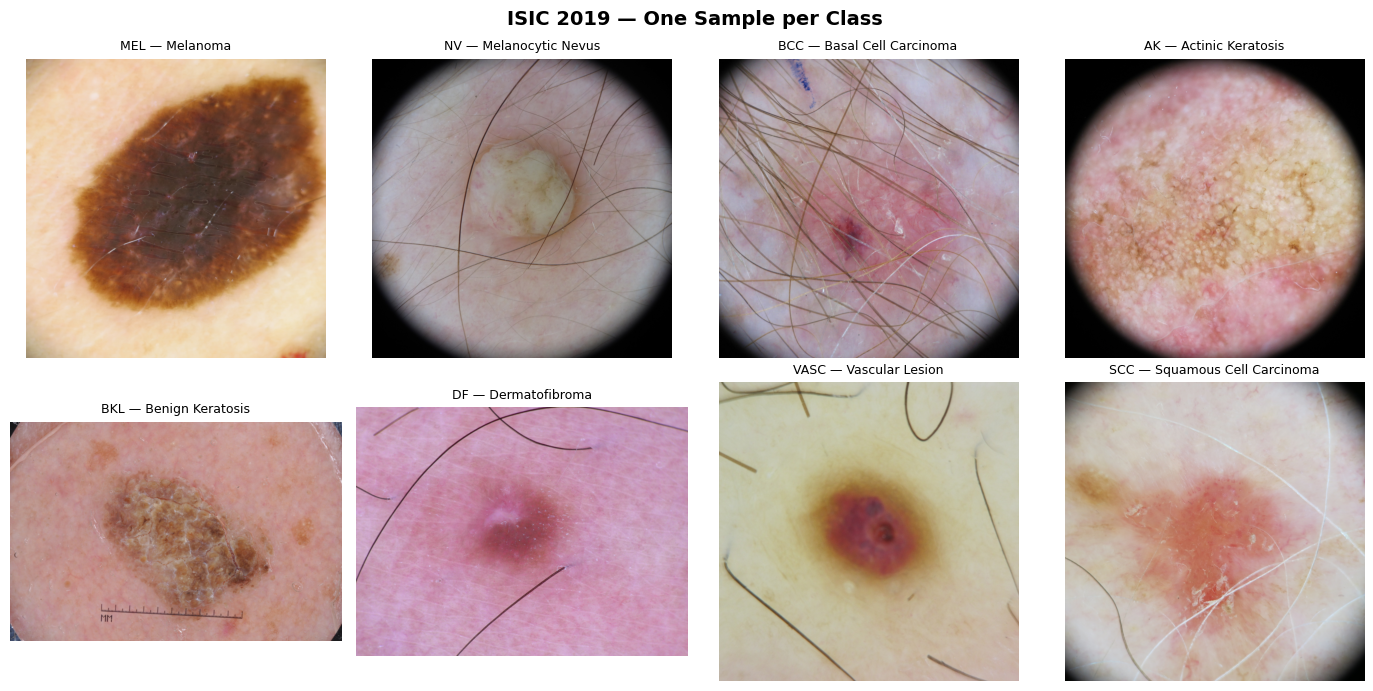

In [11]:
# Sample images grid — ISIC
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('ISIC 2019 — One Sample per Class', fontsize=14, fontweight='bold')

for ax, cls in zip(axes.flat, ISIC_LABELS):
    sample = df_is[df_is['class_name'] == cls].sample(1, random_state=42)
    img = Image.open(sample['image_path'].values[0]).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'{cls} — {full_names.get(cls, cls)}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/reports/isic_samples.png', dpi=150)
plt.show()

## 4. Preprocessing Pipeline Validation

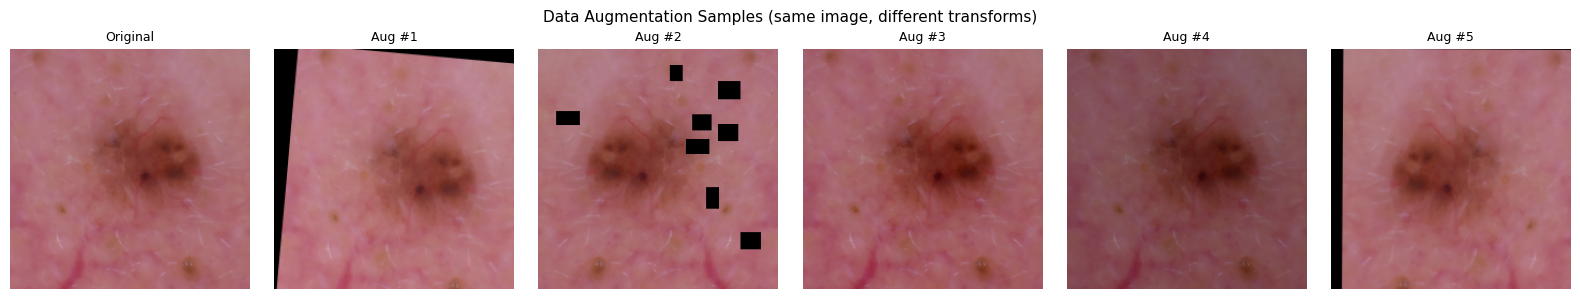

In [12]:
# Visualize augmentation effect on a single ISIC image
import albumentations as A
import numpy as np

sample_path = df_is.sample(1, random_state=7)['image_path'].values[0]
orig_img = np.array(Image.open(sample_path).convert('RGB'))

train_tfm = get_train_transforms()

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(orig_img)
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

for i, ax in enumerate(axes[1:], 1):
    aug = train_tfm(image=orig_img)['image']
    # Denormalize for display
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    disp = aug.permute(1,2,0).numpy() * std + mean
    disp = np.clip(disp, 0, 1)
    ax.imshow(disp)
    ax.set_title(f'Aug #{i}', fontsize=9)
    ax.axis('off')

fig.suptitle('Data Augmentation Samples (same image, different transforms)', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/reports/isic_samples.png', dpi=150)
plt.show()

## 5. DataLoaders & Batch Inspection

In [14]:
from src.preprocessing.preprocess import ISICDataset, split_isic, get_train_transforms, get_val_transforms
from torch.utils.data import DataLoader

# ISIC loaders only
df_is = build_isic_df_fixed(ISIC_ROOT)
is_train_df, is_val_df, is_test_df = split_isic(df_is)

is_train_ds = ISICDataset(is_train_df, transform=get_train_transforms())
is_val_ds   = ISICDataset(is_val_df,   transform=get_val_transforms())
is_test_ds  = ISICDataset(is_test_df,  transform=get_val_transforms())

is_train = DataLoader(is_train_ds, batch_size=32, shuffle=True,  num_workers=0)
is_val   = DataLoader(is_val_ds,   batch_size=32, shuffle=False, num_workers=0)
is_test  = DataLoader(is_test_ds,  batch_size=32, shuffle=False, num_workers=0)

print(f'ISIC  | Train: {len(is_train_ds):,}  Val: {len(is_val_ds):,}  Test: {len(is_test_ds):,}')
print('✓ DataLoaders ready')

Loaded 25,331 ISIC images
ISIC  | Train: 20,264  Val: 2,533  Test: 2,534
✓ DataLoaders ready


## 6. Save Split CSVs for Reproducibility

In [16]:
from src.preprocessing.preprocess import split_chestxray, split_isic

out = Path('outputs')

# ChestX-ray14
cx_train_df, cx_val_df, cx_test_df = split_chestxray(df_cx)
cx_train_df.to_csv(out / 'chestxray_train.csv', index=False)
cx_val_df.to_csv(  out / 'chestxray_val.csv',   index=False)
cx_test_df.to_csv( out / 'chestxray_test.csv',  index=False)
print(f'ChestX-ray14 splits saved.')

# ISIC
is_train_df, is_val_df, is_test_df = split_isic(df_is)
is_train_df.to_csv(out / 'isic_train.csv', index=False)
is_val_df.to_csv(  out / 'isic_val.csv',   index=False)
is_test_df.to_csv( out / 'isic_test.csv',  index=False)
print(f'ISIC splits saved.')

print('\n✓ Phase 1 complete! Splits are saved to outputs/')
print('  Next: open notebooks/02_model_training.ipynb')

ChestX-ray14 splits saved.
ISIC splits saved.

✓ Phase 1 complete! Splits are saved to outputs/
  Next: open notebooks/02_model_training.ipynb
